<a href="https://colab.research.google.com/github/aysearyavilgenoglu/ESTATEIQ/blob/main/IAT461_W5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import altair as alt
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [71]:
from google.colab import drive
df = pd.read_csv('/content/sample_data/california_housing_train.csv')
print(df.shape)
df.head()

(17000, 9)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [72]:
df["total_rooms"]

,total_rooms
0,5612.0
1,7650.0
2,720.0
3,1501.0
4,1454.0
...,...
16995,2217.0
16996,2349.0
16997,2677.0
16998,2672.0


In [73]:
scaler=MinMaxScaler()

In [74]:
df["total_rooms_minmax"]= scaler.fit_transform(df[["total_rooms"]])

In [75]:
df["total_rooms_minmax"].describe()

,total_rooms_minmax
count,17000.000000
mean,0.069637
std,0.057465
min,0.000000
25%,0.038487
50%,0.056017
75%,0.083017
max,1.000000


In [76]:
standard_scaler=StandardScaler()

In [77]:
print(df.columns.tolist())

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'total_rooms_minmax']


In [78]:
df["population_zscore"]= standard_scaler.fit_transform(df[["population"]])

In [79]:
df[["population", "population_zscore"]].describe()

,population,population_zscore
count,17000.000000,1.700000e+04
mean,1429.573941,7.356207e-17
std,1147.852959,1.000029e+00
min,3.000000,-1.242856e+00
25%,790.000000,-5.572079e-01
50%,1167.000000,-2.287590e-01
75%,1721.000000,2.538954e-01
max,35682.000000,2.984131e+01


In [80]:
df["population_log"]= np.log1p(df["population"])

In [81]:
df["population_log"]

,population_log
0,6.923629
1,7.029973
2,5.811141
3,6.246107
4,6.437752
...,...
16995,6.811244
16996,7.085901
16997,7.126891
16998,7.169350


<Axes: xlabel='population', ylabel='Count'>

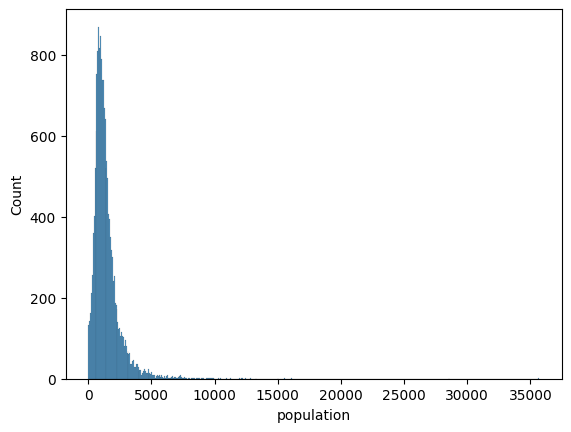

In [82]:
sns.histplot(df["population"])

<Axes: xlabel='population_log', ylabel='Count'>

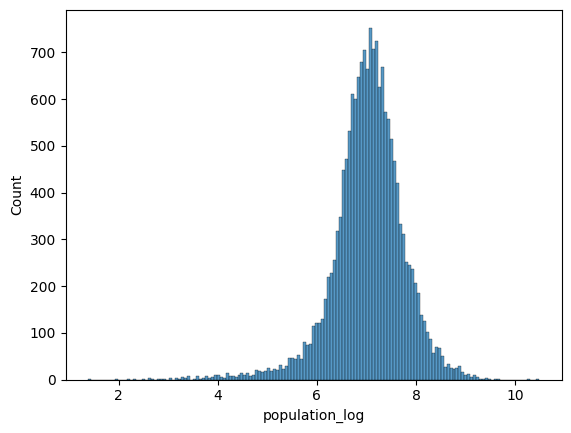

In [83]:
sns.histplot(df["population_log"])

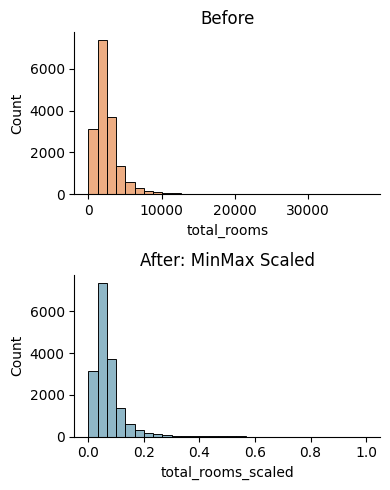

In [84]:
fig, axes= plt.subplots(2,1, figsize=(4,5))
sns.histplot(df["total_rooms"], ax=axes[0], color="#e8925a", bins=30)
axes[0].set_title("Before")
axes[0].set_xlabel("total_rooms")

sns.histplot(df["total_rooms_minmax"], ax=axes[1], color="#6a9fb5", bins=30)
axes[1].set_title("After: MinMax Scaled")
axes[1].set_xlabel("total_rooms_scaled")

sns.despine()
plt.tight_layout()
plt.show()

In [85]:
bins = [0, 1000, 3000, float("inf")]
labels = ['low', 'medium', 'high']

df["population_bin"] = pd.cut(df["population"], bins=bins, labels=labels)

<Axes: xlabel='population_bin', ylabel='count'>

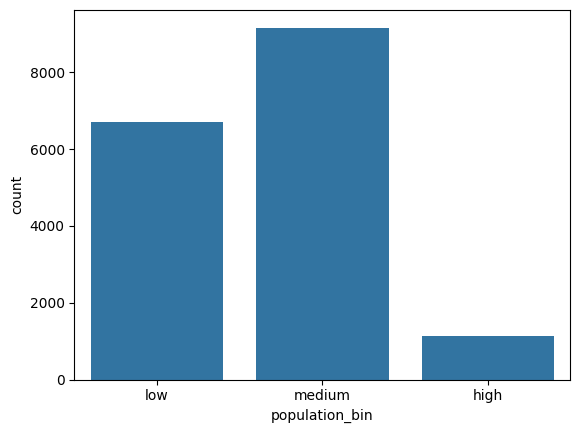

In [86]:
sns.countplot(x="population_bin", data=df)

In [87]:
df["population"].unique()

array([1015., 1129.,  333., ..., 1899.,  516., 3546.])

In [90]:
encoder=OrdinalEncoder(categories=[['low', 'medium', 'high']])
df[["population_encoded"]] = encoder.fit_transform(df[["population_bin"]]).astype(int)

In [93]:
df[["population_encoded", "population_bin"]]

,population_encoded,population_bin
0,1,medium
1,1,medium
2,0,low
3,0,low
4,0,low
...,...,...
16995,0,low
16996,1,medium
16997,1,medium
16998,1,medium


In [96]:
dummyVars= pd.get_dummies(df["total_rooms"], prefix="is")

In [97]:
dummyVars


,is_2.0,is_8.0,is_11.0,is_12.0,is_15.0,is_18.0,is_20.0,is_22.0,is_24.0,is_25.0,is_26.0,is_28.0,is_30.0,is_32.0,is_36.0,is_37.0,is_40.0,is_41.0,is_42.0,is_44.0,is_45.0,is_47.0,is_48.0,is_49.0,is_50.0,is_51.0,is_52.0,is_54.0,is_55.0,is_56.0,is_57.0,is_58.0,is_59.0,is_60.0,is_62.0,is_63.0,is_64.0,is_65.0,is_66.0,is_67.0,...,is_17738.0,is_17820.0,is_17978.0,is_18356.0,is_18392.0,is_18448.0,is_18634.0,is_18690.0,is_18767.0,is_18956.0,is_19001.0,is_19059.0,is_19107.0,is_19234.0,is_20214.0,is_20263.0,is_20377.0,is_20391.0,is_20908.0,is_20944.0,is_20982.0,is_21060.0,is_21086.0,is_21113.0,is_21533.0,is_21897.0,is_22128.0,is_23386.0,is_23866.0,is_25135.0,is_25187.0,is_25957.0,is_26322.0,is_27700.0,is_28258.0,is_30401.0,is_30405.0,is_32054.0,is_32627.0,is_37937.0
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16995,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,F

In [99]:
df= pd.concat([df, dummyVars], axis=1)


In [100]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,total_rooms_minmax,population_zscore,population_log,population_bin,population_encoded,is_2.0,is_8.0,is_11.0,is_12.0,is_15.0,is_18.0,is_20.0,is_22.0,is_24.0,is_25.0,is_26.0,is_28.0,is_30.0,is_32.0,is_36.0,is_37.0,is_40.0,is_41.0,is_42.0,is_44.0,is_45.0,is_47.0,is_48.0,is_49.0,is_50.0,is_51.0,...,is_17738.0,is_17820.0,is_17978.0,is_18356.0,is_18392.0,is_18448.0,is_18634.0,is_18690.0,is_18767.0,is_18956.0,is_19001.0,is_19059.0,is_19107.0,is_19234.0,is_20214.0,is_20263.0,is_20377.0,is_20391.0,is_20908.0,is_20944.0,is_20982.0,is_21060.0,is_21086.0,is_21113.0,is_21533.0,is_21897.0,is_22128.0,is_23386.0,is_23866.0,is_25135.0,is_25187.0,is_25957.0,is_26322.0,is_27700.0,is_28258.0,is_30401.0,is_30405.0,is_32054.0,is_32627.0,is_37937.0
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0,0.147885,-0.361184,6.923629,medium,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0,0.201608,-0.261865,7.029973,medium,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0,0.018927,-0.955354,5.811141,low,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0,0.039515,-0.796793,6.246107,low,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0,0.038276,-0.701830,6.437752,low,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16995,-124.26,40.58,52.0,2217.0,394.0,907.0,369.0,2.3571,111400.0,0.058389,-0.455275,6.811244,low,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False